# 📈 Notebook 3: Demand Forecasting and Dynamic Pricing

Gopuff’s small warehouses have **limited shelf space**. Unlike a big Amazon fulfillment center, a micro-fulfillment center (MFC) might only hold a few hundred units of each product. This makes **demand forecasting** critical — stock too little and you run out, stock too much and products expire.

On top of that, Gopuff can use **dynamic pricing** (like Uber’s surge pricing) to balance supply and demand in real time.

This notebook covers:
1. Analyzing historical demand patterns (peak hours, popular items)
2. Simple demand forecasting with moving averages
3. Dynamic pricing based on supply-demand ratio
4. Caching dynamic prices in Redis for real-time lookups

## Learning Goals

- Understand how demand varies by hour of day and item category
- Build a simple moving-average forecast
- Implement surge pricing logic that scales prices up when demand is high
- See how Redis stores real-time price overrides

## 🛠️ Setup

```bash
cd system-designs/gopuff
docker-compose up -d
```

### Kernel Selection (VS Code)
Select the `.venv` kernel (top-right).
If not visible, reload VS Code (`Cmd+Shift+P` → “Reload Window”).

In [1]:
import psycopg2
import psycopg2.extras
import redis
import json
import time
from decimal import Decimal

DB_CONFIG = {
    "host": "localhost", "port": 5432,
    "database": "gopuff", "user": "demo", "password": "demo",
}
REDIS_CONFIG = {"host": "localhost", "port": 6379, "decode_responses": True}

def get_db_connection():
    return psycopg2.connect(**DB_CONFIG)

def get_redis_client():
    return redis.Redis(**REDIS_CONFIG)

conn = get_db_connection()
cur = conn.cursor()
cur.execute("SELECT COUNT(*) FROM demand_log")
demand_count = cur.fetchone()[0]
conn.close()
r = get_redis_client()
r.ping()

print(f"✅ Connected! {demand_count} demand log entries")
print(f"✅ Redis is up")

✅ Connected! 6990 demand log entries
✅ Redis is up


## 1️⃣ Understanding Demand Patterns

Before we can forecast demand, we need to understand it. Let’s look at:
- Which hours are busiest?
- Which items sell the most?
- How does demand vary between DCs?

Think of this like a convenience store owner studying their receipts to figure out when to staff up and what to restock.

In [2]:
conn = get_db_connection()
cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

cur.execute("""
    SELECT
        EXTRACT(HOUR FROM hour_bucket)::int AS hour,
        SUM(units_sold) AS total_sold,
        SUM(units_requested) AS total_requested,
        COUNT(*) AS data_points
    FROM demand_log
    GROUP BY EXTRACT(HOUR FROM hour_bucket)
    ORDER BY hour
""")

hourly = cur.fetchall()
conn.close()

if hourly:
    max_sold = max(h['total_sold'] for h in hourly) if hourly else 1
    print("📊 Demand by Hour of Day")
    print("=" * 65)
    for h in hourly:
        bar_len = int(h['total_sold'] / max(max_sold, 1) * 30)
        bar = '█' * bar_len
        fill_rate = h['total_sold'] / max(h['total_requested'], 1) * 100
        label = "🔥" if h['total_sold'] > max_sold * 0.7 else "  "
        print(f"  {h['hour']:02d}:00 {label} {bar:<30s} {h['total_sold']:>5d} sold ({fill_rate:.0f}% fill)")
    print("\n  🔥 = Peak hours (>70% of max demand)")
else:
    print("⚠️  No demand data found. The seed data sampling may need adjustment.")

📊 Demand by Hour of Day
  00:00    ██                               159 sold (50% fill)
  01:00    █                                154 sold (55% fill)
  02:00    ██                               158 sold (54% fill)
  03:00    █                                152 sold (55% fill)
  04:00    █                                129 sold (54% fill)
  05:00    █                                126 sold (44% fill)
  06:00    █                                155 sold (50% fill)
  07:00    ████████                         657 sold (81% fill)
  08:00    ████████                         704 sold (82% fill)
  09:00    ████████                         679 sold (80% fill)
  10:00    ████████                         633 sold (86% fill)
  11:00 🔥 █████████████████████           1716 sold (72% fill)
  12:00    ████████████████████            1632 sold (72% fill)
  13:00    ████████████████████            1613 sold (75% fill)
  14:00    █████████                        766 sold (85% fill)
  15:00    ██████

### 📊 The Same Data as a Chart

ASCII bars are quick, but matplotlib makes patterns jump out. Two peaks should be obvious: **lunch (11–13)** and **dinner/evening (17–21)**.


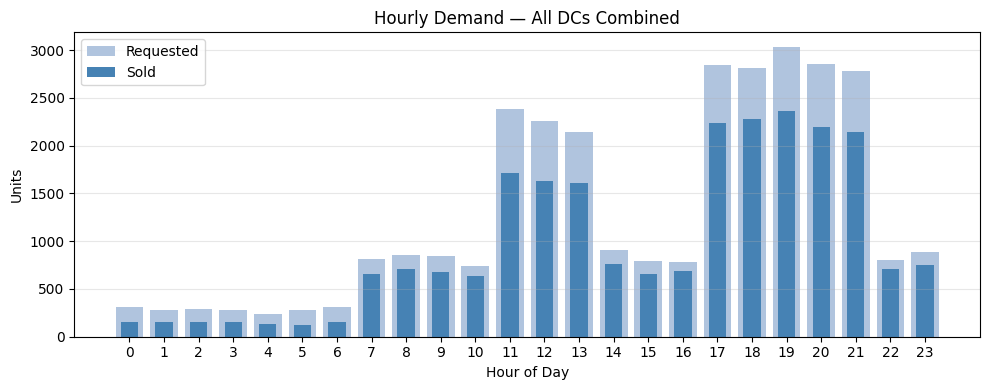

Gap between 'Requested' and 'Sold' = unmet demand (stockouts).


In [3]:
import matplotlib.pyplot as plt

conn = get_db_connection()
cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
cur.execute("""
    SELECT EXTRACT(HOUR FROM hour_bucket)::int AS hour,
           SUM(units_sold)      AS total_sold,
           SUM(units_requested) AS total_requested
    FROM demand_log
    GROUP BY hour ORDER BY hour
""")
rows = cur.fetchall()
conn.close()

hours     = [r['hour'] for r in rows]
sold      = [r['total_sold'] for r in rows]
requested = [r['total_requested'] for r in rows]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hours, requested, color='lightsteelblue', label='Requested', width=0.8)
ax.bar(hours, sold,      color='steelblue',      label='Sold',      width=0.5)
ax.set_xticks(range(0, 24))
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Units')
ax.set_title('Hourly Demand — All DCs Combined')
ax.grid(True, axis='y', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

print("Gap between 'Requested' and 'Sold' = unmet demand (stockouts).")


In [4]:
conn = get_db_connection()
cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

cur.execute("""
    SELECT
        i.name, i.category,
        SUM(dl.units_sold) AS total_sold,
        SUM(dl.units_requested) AS total_requested,
        ROUND(SUM(dl.units_sold)::decimal / NULLIF(SUM(dl.units_requested), 0) * 100) AS fill_rate
    FROM demand_log dl
    JOIN items i ON i.id = dl.item_id
    GROUP BY i.name, i.category
    ORDER BY total_sold DESC
    LIMIT 10
""")

top_items = cur.fetchall()
conn.close()

if top_items:
    print("\n🏆 Top 10 Items by Units Sold")
    print("=" * 70)
    for i, item in enumerate(top_items, 1):
        fill = item['fill_rate'] or 0
        icon = "🟢" if fill >= 90 else "🟡" if fill >= 70 else "🔴"
        print(f"  {i:2d}. {item['name']:<28s} {item['category']:<12s} "
              f"{item['total_sold']:>5d} sold  {icon} {fill:.0f}% fill rate")
else:
    print("⚠️  No demand data to analyze.")


🏆 Top 10 Items by Units Sold
   1. Gatorade Blue                Beverages      945 sold  🟡 75% fill rate
   2. Diapers Size 3 27ct          Baby           915 sold  🟡 76% fill rate
   3. AA Batteries 8-pack          Household      866 sold  🟡 74% fill rate
   4. Ice Cream Vanilla            Frozen         858 sold  🟡 83% fill rate
   5. Earbuds Wired                Electronics    846 sold  🟡 77% fill rate
   6. Lay's Classic Chips          Snacks         841 sold  🟡 79% fill rate
   7. Coca-Cola 12-pack            Beverages      839 sold  🟡 78% fill rate
   8. Frozen Burritos 8pk          Frozen         829 sold  🟡 78% fill rate
   9. Phone Charger USB-C          Electronics    817 sold  🟡 73% fill rate
  10. Baby Spinach 5oz             Produce        809 sold  🟡 81% fill rate


## 2️⃣ Simple Demand Forecasting

We’ll use a **simple moving average (SMA)** to predict upcoming demand. The idea:

> “What was the average demand for this item at this hour over the last 7 days? That’s our forecast.”

### Why Moving Average?

- **Simple to implement** — just average recent values
- **Adapts to trends** — if demand for energy drinks is rising, the average rises too
- **Smooths noise** — one random spike doesn’t throw off the forecast

In production, Gopuff would likely use ML models (ARIMA, Prophet, etc.), but the moving average is a great starting point and easy to understand.

In [5]:
def forecast_demand(dc_id, item_id, target_hour, lookback_days=7):
    """Predict demand using average of same hour over last N days."""
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cur.execute("""
        SELECT hour_bucket, units_sold, units_requested
        FROM demand_log
        WHERE dc_id = %s AND item_id = %s
          AND EXTRACT(HOUR FROM hour_bucket) = %s
          AND hour_bucket >= NOW() - make_interval(days => %s)
        ORDER BY hour_bucket DESC
    """, (dc_id, item_id, target_hour, lookback_days))
    rows = cur.fetchall()
    conn.close()

    if not rows:
        return {"forecast_sold": 0, "forecast_requested": 0, "confidence": "low", "data_points": 0}

    avg_sold = sum(r["units_sold"] for r in rows) / len(rows)
    avg_req = sum(r["units_requested"] for r in rows) / len(rows)
    confidence = "high" if len(rows) >= 5 else "medium" if len(rows) >= 3 else "low"

    return {"forecast_sold": round(avg_sold, 1), "forecast_requested": round(avg_req, 1),
            "confidence": confidence, "data_points": len(rows)}


print("🔮 Demand Forecast: Coca-Cola 12-pack at DC Downtown")
print("=" * 55)
print(f"  {'Hour':<8s} {'Forecast':>10s} {'Confidence':>12s} {'Data pts':>10s}")
print("-" * 55)
for hour in range(8, 23):
    f = forecast_demand(dc_id=1, item_id=1, target_hour=hour, lookback_days=60)
    if f['data_points'] > 0:
        emoji = "📈" if f['forecast_sold'] > 3 else "📉" if f['forecast_sold'] < 1 else "➡️"
        print(f"  {hour:02d}:00   {emoji} {f['forecast_sold']:>6.1f} units  "
              f"{f['confidence']:>10s}  {f['data_points']:>8d}")
    else:
        print(f"  {hour:02d}:00       no data")

🔮 Demand Forecast: Coca-Cola 12-pack at DC Downtown
  Hour       Forecast   Confidence   Data pts
-------------------------------------------------------
  08:00   ➡️    1.0 units         low         2
  09:00   📈    4.0 units         low         1
  10:00   📈    4.0 units         low         1
  11:00       no data
  12:00   📈    6.3 units      medium         3
  13:00       no data
  14:00   ➡️    2.0 units         low         2
  15:00       no data
  16:00   📈    4.0 units         low         1


  17:00       no data
  18:00   📈    8.5 units      medium         4


  19:00   📈    8.2 units      medium         4


  20:00   📈    9.5 units         low         2
  21:00       no data
  22:00       no data


### 📝 One Step Beyond SMA: EWMA

A **simple moving average** weights every past data point equally. But yesterday is almost always more predictive than 6 days ago. The common next step is an **exponentially weighted moving average (EWMA)**:

```
ewma_t = α · observation_t + (1 − α) · ewma_{t−1}
```

With `α ≈ 0.3`, recent hours dominate but older history still matters. Even more sophisticated? Prophet, ARIMA, or a small ML model. We stick with SMA here because you want to **understand** the forecast, not debug a model. In an interview, mention this progression (SMA → EWMA → ML) and move on.


## 3️⃣ Dynamic Pricing (Surge Pricing)

Dynamic pricing adjusts item prices based on the **supply-demand ratio**:

```
                      current_inventory
supply_ratio = ─────────────────────────
                forecasted_demand × horizon
```

- **ratio > 2.0** → Plenty of stock → maybe *discount* to move product
- **ratio 1.0–2.0** → Healthy → normal pricing
- **ratio 0.5–1.0** → Getting tight → small price increase
- **ratio < 0.5** → Running out! → surge pricing

### Why Dynamic Pricing?

1. **Prevent stockouts** — higher prices reduce demand when supply is low
2. **Maximize revenue** — charge more when customers are willing to pay
3. **Balance across DCs** — if DC East is running low but DC West has plenty, pricing can redirect demand

In [6]:
def calculate_surge_multiplier(supply_ratio):
    """Convert supply/demand ratio into a price multiplier."""
    if supply_ratio >= 2.0:
        return 0.90   # 10% discount
    elif supply_ratio >= 1.0:
        return 1.00   # Normal
    elif supply_ratio >= 0.5:
        return 1.25   # 25% surge
    elif supply_ratio >= 0.25:
        return 1.50   # 50% surge
    else:
        return 2.00   # 100% surge


print("💰 Surge Pricing Tiers")
print("=" * 50)
for ratio in [3.0, 2.0, 1.5, 1.0, 0.7, 0.5, 0.3, 0.1]:
    mult = calculate_surge_multiplier(ratio)
    base = 6.99
    surge = base * mult
    ind = "🟢" if mult <= 1.0 else "🟡" if mult <= 1.25 else "🔴"
    print(f"  {ind} Supply ratio {ratio:.1f} → {mult:.2f}x → ${base:.2f} → ${surge:.2f}")

💰 Surge Pricing Tiers
  🟢 Supply ratio 3.0 → 0.90x → $6.99 → $6.29
  🟢 Supply ratio 2.0 → 0.90x → $6.99 → $6.29
  🟢 Supply ratio 1.5 → 1.00x → $6.99 → $6.99
  🟢 Supply ratio 1.0 → 1.00x → $6.99 → $6.99
  🟡 Supply ratio 0.7 → 1.25x → $6.99 → $8.74
  🟡 Supply ratio 0.5 → 1.25x → $6.99 → $8.74
  🔴 Supply ratio 0.3 → 1.50x → $6.99 → $10.48
  🔴 Supply ratio 0.1 → 2.00x → $6.99 → $13.98


In [7]:
def compute_dynamic_price(dc_id, item_id, hours_until_restock=6):
    """Compute dynamic price based on inventory vs forecasted demand."""
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cur.execute("""
        SELECT inv.quantity, i.base_price, i.name
        FROM inventory inv JOIN items i ON i.id = inv.item_id
        WHERE inv.dc_id = %s AND inv.item_id = %s
    """, (dc_id, item_id))
    row = cur.fetchone()
    conn.close()

    if not row:
        return {"error": "Item not found at this DC"}

    current_stock = row["quantity"]
    base_price = float(row["base_price"])
    item_name = row["name"]

    import datetime
    current_hour = datetime.datetime.now().hour

    total_forecast = 0
    for h_offset in range(hours_until_restock):
        hour = (current_hour + h_offset) % 24
        f = forecast_demand(dc_id, item_id, hour, lookback_days=60)
        total_forecast += f["forecast_sold"]

    supply_ratio = current_stock / max(total_forecast, 0.1)
    multiplier = calculate_surge_multiplier(supply_ratio)
    dynamic_price = round(base_price * multiplier, 2)

    return {
        "item_name": item_name, "dc_id": dc_id,
        "current_stock": current_stock,
        "forecast_demand": round(total_forecast, 1),
        "supply_ratio": round(supply_ratio, 2),
        "base_price": base_price,
        "multiplier": multiplier,
        "dynamic_price": dynamic_price,
    }


print("💰 Dynamic Pricing — DC Downtown (next 6 hours)")
print("=" * 75)
for item_id in [1, 5, 9, 13, 16, 22]:
    result = compute_dynamic_price(dc_id=1, item_id=item_id)
    if "error" in result:
        print(f"  Item {item_id}: {result['error']}")
        continue
    ind = "🟢" if result['multiplier'] <= 1.0 else "🟡" if result['multiplier'] <= 1.25 else "🔴"
    print(f"  {ind} {result['item_name']:<24s} stock={result['current_stock']:>3d}  "
          f"forecast={result['forecast_demand']:>5.1f}  ratio={result['supply_ratio']:>4.1f}  "
          f"${result['base_price']:.2f} → ${result['dynamic_price']:.2f} ({result['multiplier']:.2f}x)")

💰 Dynamic Pricing — DC Downtown (next 6 hours)


  🟢 Coca-Cola 12-pack        stock= 48  forecast=  4.5  ratio=10.7  $6.99 → $6.29 (0.90x)


  🟢 Whole Milk Gallon        stock= 21  forecast=  1.5  ratio=14.0  $4.49 → $4.04 (0.90x)
  Item 9: Item not found at this DC


  🟢 Frozen Pizza Pepperoni   stock= 45  forecast=  1.6  ratio=28.1  $7.49 → $6.74 (0.90x)
  Item 16: Item not found at this DC
  Item 22: Item not found at this DC


### ⚠️ N+1 Query Alert

Notice that `compute_dynamic_price` calls `forecast_demand` once per hour in its forecast horizon — that's **6 round-trips to Postgres per item**. At scale, a pricing job over 10k DCs × 100k items would issue **6 × 10^9** queries. That's the textbook **N+1 query** anti-pattern.

The fix is to sum the 6 target hours in a single query. The semantics stay identical (same-hour averages over the last 60 days).


In [8]:
def compute_dynamic_price_batch(dc_id, item_id, hours_until_restock=6):
    """Same behavior as compute_dynamic_price, but one SQL query instead of N."""
    import datetime
    current_hour = datetime.datetime.now().hour
    target_hours = [(current_hour + h) % 24 for h in range(hours_until_restock)]

    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cur.execute("""
        SELECT inv.quantity, i.base_price, i.name
        FROM inventory inv JOIN items i ON i.id = inv.item_id
        WHERE inv.dc_id = %s AND inv.item_id = %s
    """, (dc_id, item_id))
    row = cur.fetchone()
    if not row:
        conn.close()
        return {"error": "Item not found at this DC"}

    # One query returns the per-hour average over the last 60 days
    # for every target hour we care about.
    cur.execute("""
        SELECT EXTRACT(HOUR FROM hour_bucket)::int AS hour,
               AVG(units_sold)::float AS avg_sold
        FROM demand_log
        WHERE dc_id = %s AND item_id = %s
          AND EXTRACT(HOUR FROM hour_bucket) = ANY(%s)
          AND hour_bucket >= NOW() - interval '60 days'
        GROUP BY hour
    """, (dc_id, item_id, target_hours))
    per_hour = {r['hour']: r['avg_sold'] for r in cur.fetchall()}
    conn.close()

    total_forecast = sum(per_hour.get(h, 0.0) for h in target_hours)
    supply_ratio = row['quantity'] / max(total_forecast, 0.1)
    multiplier = calculate_surge_multiplier(supply_ratio)
    return {
        "item_name": row['name'], "dc_id": dc_id,
        "current_stock": row['quantity'],
        "forecast_demand": round(total_forecast, 1),
        "supply_ratio": round(supply_ratio, 2),
        "base_price": float(row['base_price']),
        "multiplier": multiplier,
        "dynamic_price": round(float(row['base_price']) * multiplier, 2),
    }


# Sanity check: the batch version should match the slow version
slow = compute_dynamic_price(dc_id=1, item_id=1)
fast = compute_dynamic_price_batch(dc_id=1, item_id=1)
print(f"  slow: stock={slow['current_stock']}  demand={slow['forecast_demand']}  "
      f"ratio={slow['supply_ratio']}  price=${slow['dynamic_price']}")
print(f"  fast: stock={fast['current_stock']}  demand={fast['forecast_demand']}  "
      f"ratio={fast['supply_ratio']}  price=${fast['dynamic_price']}")


  slow: stock=48  demand=4.5  ratio=10.67  price=$6.29
  fast: stock=48  demand=4.5  ratio=10.67  price=$6.29


## 4️⃣ Storing Dynamic Prices in Redis

Dynamic prices change frequently. We store them in **Redis** for fast real-time lookups, and periodically persist to Postgres for audit/history.

```
Price Computation Job (runs every 5 min)
       │
       ├── Read inventory from Postgres
       ├── Read demand forecast
       ├── Compute surge multipliers
       │
       ├── Write to Redis (real-time lookups)
       └── Write to Postgres dynamic_prices table (audit trail)
```

In [9]:
def update_dynamic_prices(dc_id):
    """Recompute and cache dynamic prices for all items at a DC."""
    r = get_redis_client()
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cur.execute("""
        SELECT inv.item_id, inv.quantity, i.base_price, i.name
        FROM inventory inv JOIN items i ON i.id = inv.item_id
        WHERE inv.dc_id = %s
    """, (dc_id,))
    items = cur.fetchall()
    conn.close()

    updated = 0
    for item in items:
        result = compute_dynamic_price(dc_id, item['item_id'])
        if 'error' in result:
            continue
        price_key = f"price:{dc_id}:{item['item_id']}"
        r.hset(price_key, mapping={
            "base_price": str(result['base_price']),
            "dynamic_price": str(result['dynamic_price']),
            "multiplier": str(result['multiplier']),
            "supply_ratio": str(result['supply_ratio']),
        })
        r.expire(price_key, 600)
        updated += 1
    return updated


def get_current_price(dc_id, item_id):
    """Get dynamic price from Redis, fall back to Postgres base price."""
    r = get_redis_client()
    cached = r.hgetall(f"price:{dc_id}:{item_id}")
    if cached:
        return {"source": "redis", "base_price": float(cached["base_price"]),
                "dynamic_price": float(cached["dynamic_price"]),
                "multiplier": float(cached["multiplier"])}

    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cur.execute("SELECT base_price FROM items WHERE id = %s", (item_id,))
    row = cur.fetchone()
    conn.close()
    if row:
        return {"source": "postgres_fallback", "base_price": float(row["base_price"]),
                "dynamic_price": float(row["base_price"]), "multiplier": 1.0}
    return {"error": "Item not found"}


r = get_redis_client()
r.flushdb()
print("Updating dynamic prices for DC Downtown...")
count = update_dynamic_prices(dc_id=1)
print(f"✅ Updated {count} item prices in Redis\n")

print("📋 Current Dynamic Prices (from Redis)")
print("=" * 55)
for item_id in [1, 5, 9, 13, 16]:
    start = time.time()
    p = get_current_price(dc_id=1, item_id=item_id)
    elapsed = (time.time() - start) * 1000
    if 'error' not in p:
        print(f"  Item {item_id:2d}: ${p['dynamic_price']:.2f} "
              f"({p['multiplier']:.2f}x) [{p['source']}, {elapsed:.1f}ms]")

Updating dynamic prices for DC Downtown...


✅ Updated 18 item prices in Redis

📋 Current Dynamic Prices (from Redis)
  Item  1: $6.29 (0.90x) [redis, 3.6ms]
  Item  5: $4.04 (0.90x) [redis, 2.8ms]
  Item  9: $5.49 (1.00x) [postgres_fallback, 21.9ms]
  Item 13: $6.74 (0.90x) [redis, 2.9ms]
  Item 16: $1.29 (1.00x) [postgres_fallback, 22.5ms]


## 5️⃣ Simulating Demand Spikes

Let’s see dynamic pricing in action. We’ll simulate a demand spike (e.g., a hot day drives up drink sales) and watch the prices adjust.

In [10]:
conn = get_db_connection()
cur = conn.cursor()
cur.execute("UPDATE inventory SET quantity = 50 WHERE dc_id = 1 AND item_id = 1")
conn.commit()
conn.close()

print("🔥 Simulating Demand Spike: Coca-Cola at DC Downtown")
print("=" * 60)
print(f"  {'Stock':>6s}  {'Ratio':>6s}  {'Mult':>5s}  {'Price':>7s}  Visual")
print("-" * 60)

for stock in [50, 40, 30, 20, 15, 10, 5, 2, 1]:
    conn = get_db_connection()
    cur = conn.cursor()
    cur.execute("UPDATE inventory SET quantity = %s WHERE dc_id = 1 AND item_id = 1", (stock,))
    conn.commit()
    conn.close()

    result = compute_dynamic_price(dc_id=1, item_id=1)
    if 'error' in result:
        continue

    stock_bar = '█' * (stock // 2)
    price_ind = '💰' * (int(result['multiplier'] * 2) - 1)
    print(f"  {stock:>5d}   {result['supply_ratio']:>5.1f}  {result['multiplier']:>4.2f}x "
          f" ${result['dynamic_price']:>5.2f}  {stock_bar} {price_ind}")

conn = get_db_connection()
cur = conn.cursor()
cur.execute("UPDATE inventory SET quantity = 50 WHERE dc_id = 1 AND item_id = 1")
conn.commit()
conn.close()
print("\n(Stock reset to 50)")

🔥 Simulating Demand Spike: Coca-Cola at DC Downtown
   Stock   Ratio   Mult    Price  Visual
------------------------------------------------------------


     50    11.1  0.90x  $ 6.29  █████████████████████████ 


     40     8.9  0.90x  $ 6.29  ████████████████████ 


     30     6.7  0.90x  $ 6.29  ███████████████ 


     20     4.4  0.90x  $ 6.29  ██████████ 


     15     3.3  0.90x  $ 6.29  ███████ 


     10     2.2  0.90x  $ 6.29  █████ 


      5     1.1  1.00x  $ 6.99  ██ 💰


      2     0.4  1.50x  $10.48  █ 💰💰


      1     0.2  2.00x  $13.98   💰💰💰

(Stock reset to 50)


## 6️⃣ Restock Alerts

When forecasted demand exceeds current stock, the system should alert the warehouse team to restock. Let’s build a simple restock alert.

In [11]:
def check_restock_alerts(dc_id, hours_ahead=8):
    """Check which items risk running out in the next N hours."""
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)
    cur.execute("""
        SELECT inv.item_id, inv.quantity, inv.reorder_point, i.name, i.category
        FROM inventory inv JOIN items i ON i.id = inv.item_id
        WHERE inv.dc_id = %s ORDER BY i.category, i.name
    """, (dc_id,))
    items = cur.fetchall()
    conn.close()

    import datetime
    current_hour = datetime.datetime.now().hour

    alerts = []
    for item in items:
        total_forecast = 0
        for h_offset in range(hours_ahead):
            hour = (current_hour + h_offset) % 24
            f = forecast_demand(dc_id, item['item_id'], hour, lookback_days=60)
            total_forecast += f['forecast_sold']

        projected = item['quantity'] - total_forecast
        if projected < item['reorder_point']:
            urgency = "🔴 CRITICAL" if projected < 0 else "🟡 WARNING"
            alerts.append({
                "item_name": item['name'], "category": item['category'],
                "current_stock": item['quantity'],
                "forecast_demand": round(total_forecast, 1),
                "projected_stock": round(projected, 1),
                "reorder_point": item['reorder_point'],
                "urgency": urgency,
            })

    alerts.sort(key=lambda x: x['projected_stock'])
    return alerts


alerts = check_restock_alerts(dc_id=1, hours_ahead=8)
print(f"⚠️  Restock Alerts — DC Downtown (next 8 hours)")
print("=" * 75)
if alerts:
    for a in alerts[:10]:
        print(f"  {a['urgency']:<14s} {a['item_name']:<24s} "
              f"stock={a['current_stock']:>3d}  demand={a['forecast_demand']:>5.1f}  "
              f"projected={a['projected_stock']:>5.1f}")
else:
    print("  ✅ All items have sufficient stock!")

⚠️  Restock Alerts — DC Downtown (next 8 hours)
  🔴 CRITICAL     Avocados 3-pack          stock=  0  demand=  2.0  projected= -2.0
  🟡 WARNING      Trash Bags 30ct          stock= 17  demand= 10.0  projected=  7.0


## 🔑 Key Takeaways

| Concept | What We Did |
|---------|-------------|
| **Demand patterns** | Analyzed hourly and per-item demand from historical logs |
| **Moving average forecast** | Predicted demand using recent same-hour averages |
| **Surge pricing** | Computed price multipliers based on supply/demand ratio |
| **Redis price cache** | Stored dynamic prices in Redis for sub-ms lookups |
| **Restock alerts** | Compared forecast demand vs current stock to flag shortages |

### Interview Tip

Dynamic pricing in the interview context ties into the **scaling reads** pattern. Price data changes frequently and is read on every product page view. By computing prices in a background job and caching in Redis:
- Read path is O(1) Redis lookup
- Computation runs asynchronously, not in the request path
- TTL provides a safety net if the job fails

This is the same pattern used by Uber (surge pricing), airlines (yield management), and e-commerce flash sales.

## 🧹 Cleanup

In [12]:
r = get_redis_client()
keys = r.keys("price:*")
if keys:
    r.delete(*keys)
    print(f"🧹 Cleaned up {len(keys)} Redis price keys")
else:
    print("🧹 Nothing to clean up")

🧹 Cleaned up 18 Redis price keys
